MODEL SAMPLING-BASED PLANNING AND DATA GENERATION
Grid World Game


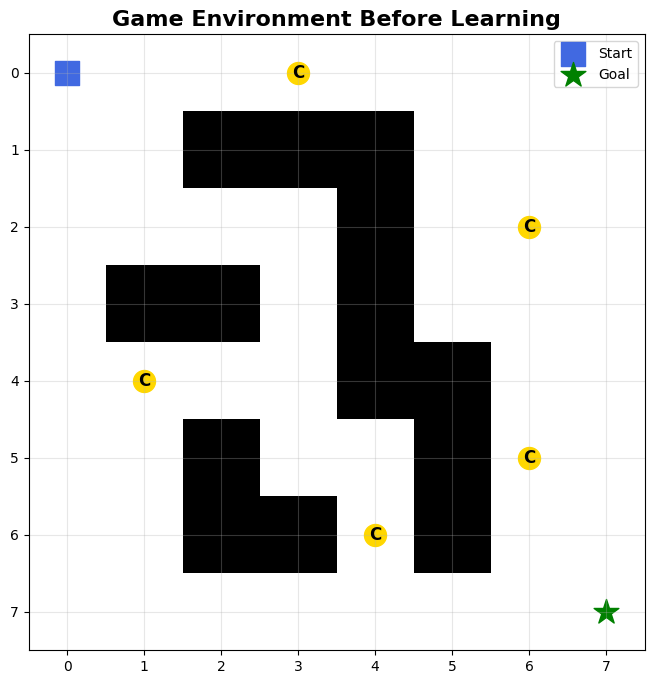

Episode: 50 | Reward: -27 | Steps: 73 | Real Data: 3232 | Generated Data: 64640
Episode: 100 | Reward: 57 | Steps: 21 | Real Data: 4884 | Generated Data: 97680
Episode: 150 | Reward: 61 | Steps: 17 | Real Data: 6206 | Generated Data: 124120
Episode: 200 | Reward: 49 | Steps: 29 | Real Data: 7447 | Generated Data: 148940
Episode: 250 | Reward: 47 | Steps: 31 | Real Data: 8635 | Generated Data: 172700
Episode: 300 | Reward: 49 | Steps: 29 | Real Data: 9861 | Generated Data: 197220


TRAINING COMPLETED
Real Experiences: 9861
Generated Experiences: 197220
Training Time: 24.16 seconds


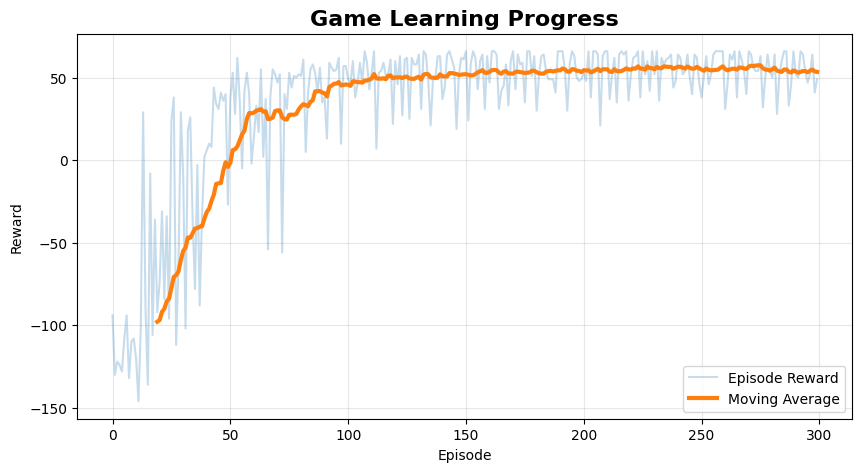

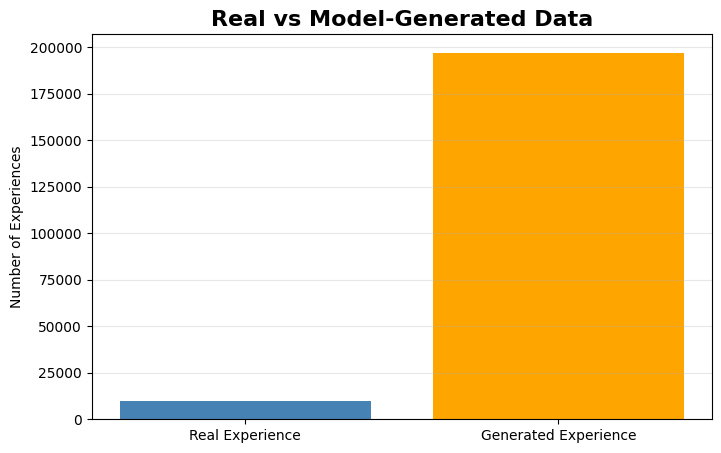

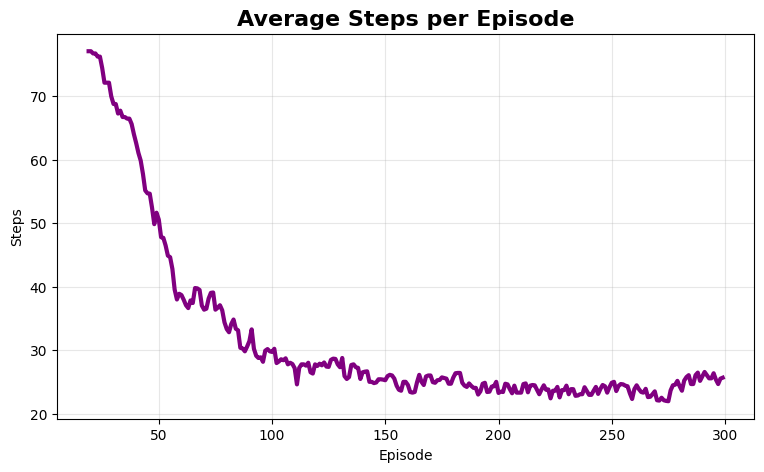

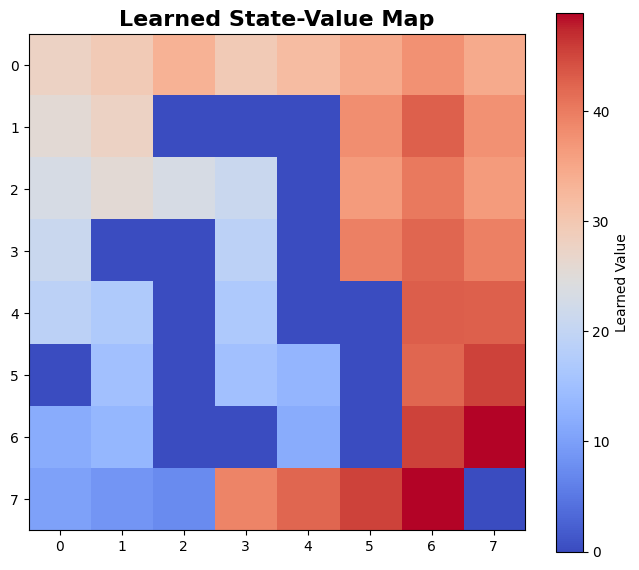

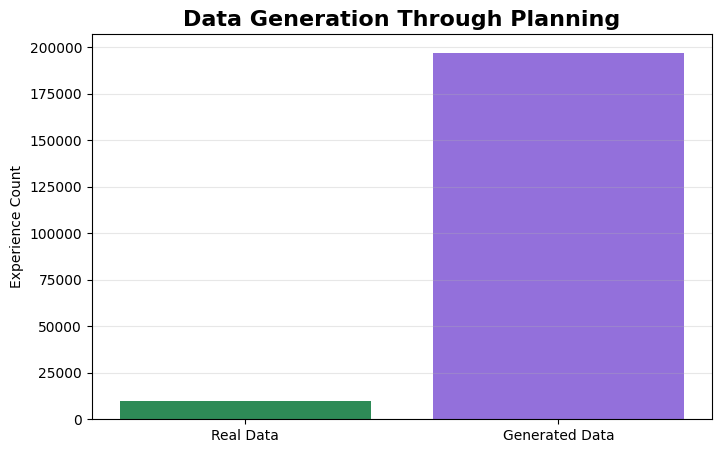

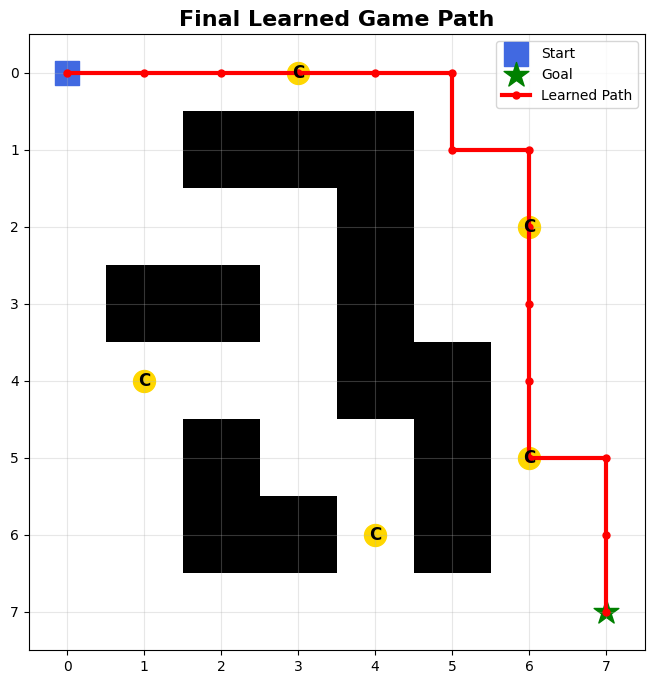



FINAL GAME PERFORMANCE
Final Average Reward: 54.23
Best Reward: 66
Final Average Steps: 25.17
Real Experiences: 9861
Generated Experiences: 197220
Planning Data Ratio: 20.0
Training Time: 24.16 seconds


SUMMARY TABLE


,Measure,Result
0,Environment,Grid World Game
1,Grid Size,8 x 8
2,Episodes,300
3,Planning Steps,20
4,Real Experiences,9861
5,Generated Experiences,197220
6,Final Average Reward,54.23
7,Best Reward,66
8,Final Average Steps,25.17
9,Planning Data Ratio,20.0




CONCLUSION
A Grid World game was successfully developed
using model sampling-based planning.
The agent collected real experiences while
interacting with the game environment.
A transition model was learned from these experiences.
The learned model was then sampled to generate
additional planning experiences.
These generated experiences were used to update
the Q-values without requiring direct interaction.
The final learned path demonstrates the effect
of model-based planning on game performance.

Files Created:
1. Real_Game_Experience.csv
2. Generated_Planning_Experience.csv
3. Game_Training_Results.csv
4. Model_Sampling_Planning_Summary.csv

Model Sampling-Based Planning Game Completed.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output

np.random.seed(42)
random.seed(42)

print("="*75)
print("MODEL SAMPLING-BASED PLANNING AND DATA GENERATION")
print("Grid World Game")
print("="*75)

SIZE=8
EPISODES=300
MAX_STEPS=80
PLANNING_STEPS=20
ALPHA=0.15
GAMMA=0.95
EPSILON=1.0
EPSILON_MIN=0.05
EPSILON_DECAY=0.985

ACTIONS=[
    (-1,0),
    (1,0),
    (0,-1),
    (0,1)
]

ACTION_SYMBOLS=[
    "↑",
    "↓",
    "←",
    "→"
]

START=(0,0)
GOAL=(7,7)

OBSTACLES={
    (1,2),(1,3),(1,4),
    (2,4),
    (3,1),(3,2),(3,4),
    (4,4),(4,5),
    (5,2),(5,5),
    (6,2),(6,3),(6,5)
}

COINS={
    (0,3),
    (2,6),
    (4,1),
    (5,6),
    (6,4)
}

def state_id(pos):
    return pos[0]*SIZE+pos[1]

def inside(pos):
    return (
        0<=pos[0]<SIZE and
        0<=pos[1]<SIZE
    )

def move(pos,action):
    dr,dc=ACTIONS[action]

    new_pos=(
        pos[0]+dr,
        pos[1]+dc
    )

    if not inside(new_pos):
        return pos

    if new_pos in OBSTACLES:
        return pos

    return new_pos

def environment_step(pos,action,collected):

    next_pos=move(pos,action)

    reward=-1

    if next_pos==pos:
        reward=-3

    if next_pos in COINS and next_pos not in collected:
        reward+=10
        collected.add(next_pos)

    done=False

    if next_pos==GOAL:
        reward+=50
        done=True

    return next_pos,reward,done

def show_game(path=None,title="Grid World"):

    board=np.zeros(
        (SIZE,SIZE)
    )

    for r,c in OBSTACLES:
        board[r,c]=1

    plt.figure(figsize=(8,8))

    plt.imshow(
        board,
        cmap="Greys"
    )

    for r,c in COINS:
        plt.scatter(
            c,
            r,
            s=250,
            marker="o",
            color="gold"
        )
        plt.text(
            c,
            r,
            "C",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

    plt.scatter(
        START[1],
        START[0],
        s=300,
        marker="s",
        color="royalblue",
        label="Start"
    )

    plt.scatter(
        GOAL[1],
        GOAL[0],
        s=350,
        marker="*",
        color="green",
        label="Goal"
    )

    if path is not None and len(path)>1:

        y=[p[0] for p in path]
        x=[p[1] for p in path]

        plt.plot(
            x,
            y,
            color="red",
            linewidth=3,
            marker="o",
            markersize=5,
            label="Learned Path"
        )

    plt.xticks(range(SIZE))
    plt.yticks(range(SIZE))

    plt.grid(
        True,
        alpha=0.3
    )

    plt.title(
        title,
        fontsize=16,
        fontweight="bold"
    )

    plt.legend()
    plt.show()

show_game(
    title="Game Environment Before Learning"
)

Q=np.zeros(
    (SIZE*SIZE,4)
)

transition_counts=np.zeros(
    (SIZE*SIZE,4,SIZE*SIZE)
)

reward_model=np.zeros(
    (SIZE*SIZE,4)
)

experience=[]

generated_experience=[]

episode_rewards=[]
episode_steps=[]
real_samples=[]
generated_samples=[]

epsilon=EPSILON

start_time=time.time()

for episode in range(EPISODES):

    position=START
    collected=set()

    total_reward=0
    steps=0

    done=False

    while not done and steps<MAX_STEPS:

        s=state_id(position)

        if np.random.random()<epsilon:
            action=np.random.randint(4)
        else:
            action=int(
                np.argmax(Q[s])
            )

        next_position,reward,done=environment_step(
            position,
            action,
            collected
        )

        ns=state_id(next_position)

        experience.append([
            episode+1,
            s,
            action,
            ns,
            reward
        ])

        transition_counts[
            s,
            action,
            ns
        ]+=1

        reward_model[
            s,
            action
        ]=reward

        target=reward

        if not done:
            target+=GAMMA*np.max(
                Q[ns]
            )

        Q[s,action]+=ALPHA*(
            target-Q[s,action]
        )

        total_reward+=reward
        position=next_position
        steps+=1

        if np.sum(
            transition_counts
        )>0:

            for _ in range(PLANNING_STEPS):

                known_states=np.where(
                    transition_counts.sum(
                        axis=(1,2)
                    )>0
                )[0]

                if len(known_states)==0:
                    continue

                ps=int(
                    np.random.choice(
                        known_states
                    )
                )

                known_actions=np.where(
                    transition_counts[
                        ps
                    ].sum(axis=1)>0
                )[0]

                if len(known_actions)==0:
                    continue

                pa=int(
                    np.random.choice(
                        known_actions
                    )
                )

                transition=transition_counts[
                    ps,
                    pa
                ]

                predicted_next=int(
                    np.argmax(transition)
                )

                predicted_reward=reward_model[
                    ps,
                    pa
                ]

                generated_experience.append([
                    episode+1,
                    ps,
                    pa,
                    predicted_next,
                    predicted_reward
                ])

                planning_target=predicted_reward

                if predicted_next!=state_id(GOAL):
                    planning_target+=(
                        GAMMA*
                        np.max(
                            Q[predicted_next]
                        )
                    )

                Q[ps,pa]+=ALPHA*(
                    planning_target-Q[ps,pa]
                )

    epsilon=max(
        EPSILON_MIN,
        epsilon*EPSILON_DECAY
    )

    episode_rewards.append(
        total_reward
    )

    episode_steps.append(
        steps
    )

    real_samples.append(
        len(experience)
    )

    generated_samples.append(
        len(generated_experience)
    )

    if (episode+1)%50==0:
        print(
            "Episode:",
            episode+1,
            "| Reward:",
            round(total_reward,2),
            "| Steps:",
            steps,
            "| Real Data:",
            len(experience),
            "| Generated Data:",
            len(generated_experience)
        )

training_time=time.time()-start_time

real_df=pd.DataFrame(
    experience,
    columns=[
        "Episode",
        "State",
        "Action",
        "Next_State",
        "Reward"
    ]
)

generated_df=pd.DataFrame(
    generated_experience,
    columns=[
        "Episode",
        "State",
        "Action",
        "Next_State",
        "Reward"
    ]
)

episode_df=pd.DataFrame({
    "Episode":range(1,EPISODES+1),
    "Reward":episode_rewards,
    "Steps":episode_steps,
    "Real_Experiences":real_samples,
    "Generated_Experiences":generated_samples
})

real_df.to_csv(
    "Real_Game_Experience.csv",
    index=False
)

generated_df.to_csv(
    "Generated_Planning_Experience.csv",
    index=False
)

episode_df.to_csv(
    "Game_Training_Results.csv",
    index=False
)

print("\n")
print("="*75)
print("TRAINING COMPLETED")
print("="*75)

print(
    "Real Experiences:",
    len(real_df)
)

print(
    "Generated Experiences:",
    len(generated_df)
)

print(
    "Training Time:",
    round(training_time,2),
    "seconds"
)

reward_smooth=episode_df[
    "Reward"
].rolling(20).mean()

plt.figure(figsize=(10,5))

plt.plot(
    episode_df["Reward"],
    alpha=0.25,
    label="Episode Reward"
)

plt.plot(
    reward_smooth,
    linewidth=3,
    label="Moving Average"
)

plt.title(
    "Game Learning Progress",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Reward")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,5))

plt.bar(
    [
        "Real Experience",
        "Generated Experience"
    ],
    [
        len(real_df),
        len(generated_df)
    ],
    color=[
        "steelblue",
        "orange"
    ]
)

plt.title(
    "Real vs Model-Generated Data",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Experiences")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

plt.figure(figsize=(9,5))

plt.plot(
    episode_df["Steps"].rolling(20).mean(),
    linewidth=3,
    color="purple"
)

plt.title(
    "Average Steps per Episode",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Steps")

plt.grid(alpha=0.3)

plt.show()

state_values=np.max(
    Q,
    axis=1
)

value_grid=state_values.reshape(
    SIZE,
    SIZE
)

plt.figure(figsize=(8,7))

plt.imshow(
    value_grid,
    cmap="coolwarm"
)

plt.colorbar(
    label="Learned Value"
)

plt.title(
    "Learned State-Value Map",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(range(SIZE))
plt.yticks(range(SIZE))

plt.show()

planning_ratio=(
    len(generated_df)/
    max(len(real_df),1)
)

plt.figure(figsize=(8,5))

plt.bar(
    [
        "Real Data",
        "Generated Data"
    ],
    [
        len(real_df),
        len(generated_df)
    ],
    color=[
        "seagreen",
        "mediumpurple"
    ]
)

plt.title(
    "Data Generation Through Planning",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Experience Count")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

position=START
path=[position]
collected=set()

for step in range(MAX_STEPS):

    s=state_id(position)

    action=int(
        np.argmax(Q[s])
    )

    next_position,reward,done=environment_step(
        position,
        action,
        collected
    )

    path.append(
        next_position
    )

    position=next_position

    if done:
        break

if len(path)>1:

    show_game(
        path,
        "Final Learned Game Path"
    )

print("\n")
print("="*75)
print("FINAL GAME PERFORMANCE")
print("="*75)

final_reward=np.mean(
    episode_df["Reward"].tail(30)
)

best_reward=episode_df["Reward"].max()

final_steps=np.mean(
    episode_df["Steps"].tail(30)
)

print(
    "Final Average Reward:",
    round(final_reward,2)
)

print(
    "Best Reward:",
    round(best_reward,2)
)

print(
    "Final Average Steps:",
    round(final_steps,2)
)

print(
    "Real Experiences:",
    len(real_df)
)

print(
    "Generated Experiences:",
    len(generated_df)
)

print(
    "Planning Data Ratio:",
    round(planning_ratio,2)
)

print(
    "Training Time:",
    round(training_time,2),
    "seconds"
)

summary=pd.DataFrame({
    "Measure":[
        "Environment",
        "Grid Size",
        "Episodes",
        "Planning Steps",
        "Real Experiences",
        "Generated Experiences",
        "Final Average Reward",
        "Best Reward",
        "Final Average Steps",
        "Planning Data Ratio"
    ],
    "Result":[
        "Grid World Game",
        "8 x 8",
        EPISODES,
        PLANNING_STEPS,
        len(real_df),
        len(generated_df),
        round(final_reward,2),
        round(best_reward,2),
        round(final_steps,2),
        round(planning_ratio,2)
    ]
})

print("\n")
print("="*75)
print("SUMMARY TABLE")
print("="*75)

display(summary)

summary.to_csv(
    "Model_Sampling_Planning_Summary.csv",
    index=False
)

print("\n")
print("="*75)
print("CONCLUSION")
print("="*75)

print(
    "A Grid World game was successfully developed"
)

print(
    "using model sampling-based planning."
)

print(
    "The agent collected real experiences while"
)

print(
    "interacting with the game environment."
)

print(
    "A transition model was learned from these experiences."
)

print(
    "The learned model was then sampled to generate"
)

print(
    "additional planning experiences."
)

print(
    "These generated experiences were used to update"
)

print(
    "the Q-values without requiring direct interaction."
)

print(
    "The final learned path demonstrates the effect"
)

print(
    "of model-based planning on game performance."
)

print("\nFiles Created:")
print("1. Real_Game_Experience.csv")
print("2. Generated_Planning_Experience.csv")
print("3. Game_Training_Results.csv")
print("4. Model_Sampling_Planning_Summary.csv")

print("\nModel Sampling-Based Planning Game Completed.")